In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

<>:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\ptimb\AppData\Local\Temp\ipykernel_5748\3665082687.py:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  orders = pd.read_csv('archive\olist_orders_dataset.csv')


6.7595444675671335


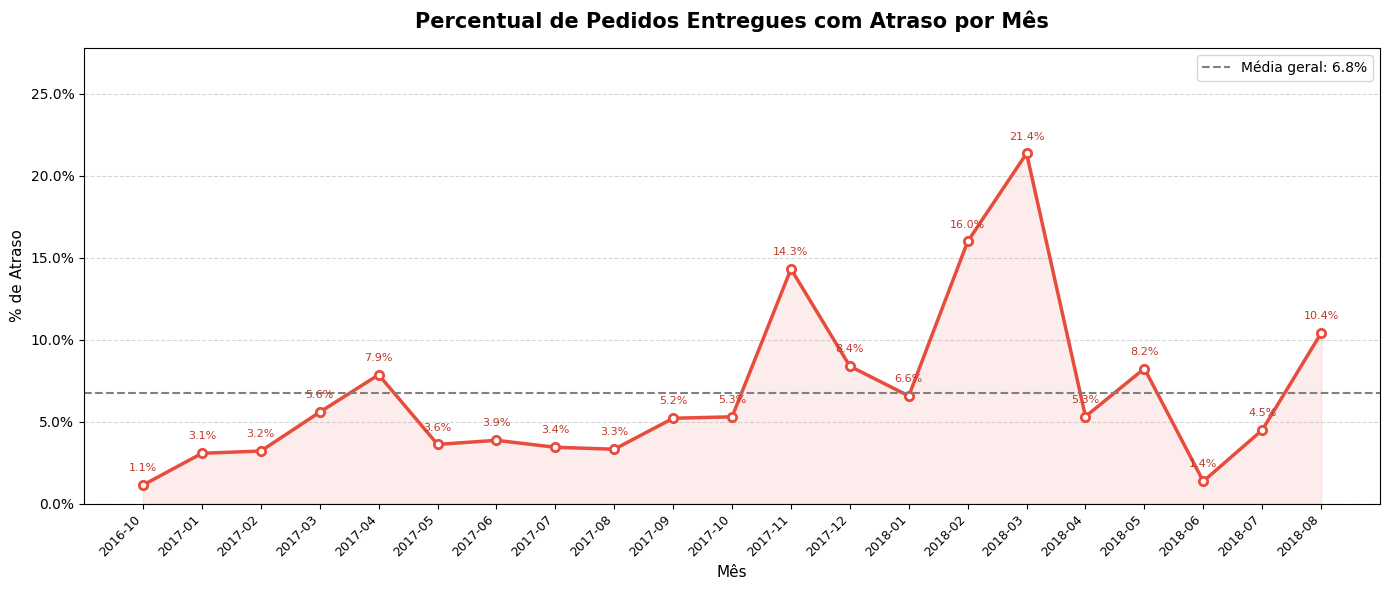

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Carrega os dados
orders = pd.read_csv('archive\olist_orders_dataset.csv')

# Converte datas
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Filtra apenas entregues e remove nulos
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered = delivered.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'])

# Cria coluna de atraso e coluna de ano/mês
delivered['entregue_com_atraso'] = (
    delivered['order_delivered_customer_date'] > delivered['order_estimated_delivery_date']
)
delivered['ano_mes'] = delivered['order_purchase_timestamp'].dt.to_period('M')

# Agrupa por mês
mensal = delivered.groupby('ano_mes').agg(
    total=('entregue_com_atraso', 'count'),
    atrasados=('entregue_com_atraso', 'sum')
).reset_index()

mensal['percentual_atraso'] = (mensal['atrasados'] / mensal['total']) * 100
mensal['ano_mes_str'] = mensal['ano_mes'].astype(str)

# Remove meses com poucos pedidos (evita distorções nas pontas)
mensal = mensal[mensal['total'] >= 100]

# ---- Gráfico ----
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    mensal['ano_mes_str'],
    mensal['percentual_atraso'],
    color='#E74C3C',
    linewidth=2.5,
    marker='o',
    markersize=6,
    markerfacecolor='white',
    markeredgewidth=2
)

# Área sombreada abaixo da linha
ax.fill_between(mensal['ano_mes_str'], mensal['percentual_atraso'], alpha=0.1, color='#E74C3C')

# Linha de média geral
media = mensal['percentual_atraso'].mean()
print(media)
ax.axhline(media, color='gray', linestyle='--', linewidth=1.5, label=f'Média geral: {media:.1f}%')

# Anotação em cada ponto
for _, row in mensal.iterrows():
    ax.annotate(
        f"{row['percentual_atraso']:.1f}%",
        xy=(row['ano_mes_str'], row['percentual_atraso']),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color='#C0392B'
    )

# Formatação
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(mensal['ano_mes_str'])
ax.set_xticklabels(mensal['ano_mes_str'], rotation=45, ha='right', fontsize=9)
ax.set_title('Percentual de Pedidos Entregues com Atraso por Mês', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('% de Atraso', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(0, mensal['percentual_atraso'].max() * 1.3)

plt.tight_layout()
plt.savefig('atraso_por_mes.png', dpi=150)
plt.show()